# Airline Passenger Satisfaction Analysis: Key Drivers of Customer Experience

## Project Objective

The objective of this project is to identify the factors that have the greatest impact on airline passenger satisfaction and provide data-driven recommendations to improve customer experience.

## Business Question

What factors have the greatest impact on airline passenger satisfaction?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
import os

print(os.listdir('/'))

['media', 'proc', 'libx32', 'usr', 'sbin', 'run', 'opt', 'lib', 'dev', 'mnt', 'root', 'lib32', 'var', 'boot', 'srv', 'sys', 'lib64', 'etc', 'bin', 'home', 'tmp', 'kaggle', '.dockerenv', 'tools', 'datalab', 'content', 'python-apt', 'python-apt.tar.xz']


In [4]:
import os

print(os.listdir('/content'))

['.config', 'train.csv', 'sample_data']


In [5]:
import pandas as pd

df = pd.read_csv('/content/train.csv')

print("Dataset loaded successfully")
print(df.shape)

Dataset loaded successfully
(103904, 25)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 25 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Unnamed: 0                         103904 non-null  int64  
 1   id                                 103904 non-null  int64  
 2   Gender                             103904 non-null  object 
 3   Customer Type                      103904 non-null  object 
 4   Age                                103904 non-null  int64  
 5   Type of Travel                     103904 non-null  object 
 6   Class                              103904 non-null  object 
 7   Flight Distance                    103904 non-null  int64  
 8   Inflight wifi service              103904 non-null  int64  
 9   Departure/Arrival time convenient  103904 non-null  int64  
 10  Ease of Online booking             103904 non-null  int64  
 11  Gate location                      1039

In [7]:
df.isnull().sum().sort_values(ascending=False)

,0
Arrival Delay in Minutes,310
id,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Unnamed: 0,0
Inflight wifi service,0


## Data Cleaning

Before conducting the analysis, the dataset was inspected for missing values and data quality issues.

One variable, `Arrival Delay in Minutes`, contained 310 missing values. Since this represents less than 0.3% of the dataset, the missing values were replaced using the median value of the column to preserve the distribution and avoid removing observations.

In [8]:
# Remove unnecessary index column

df = df.drop("Unnamed: 0", axis=1)

# Fill missing values using median

df["Arrival Delay in Minutes"] = df[
    "Arrival Delay in Minutes"
].fillna(
    df["Arrival Delay in Minutes"].median()
)

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 103904
Columns: 24


# 2. Exploratory Data Analysis

The goal of this section is to understand the overall passenger satisfaction distribution and identify patterns that may explain differences between satisfied and dissatisfied passengers.

### Dataset Note

The original dataset groups passengers into two categories:

- Satisfied
- Neutral or Dissatisfied

Therefore, the analysis compares satisfied passengers against passengers who are not fully satisfied.

## Business Question 1

### How satisfied are airline passengers overall?

Before analyzing the factors that influence satisfaction, it is important to establish a baseline by understanding the overall distribution of passenger satisfaction in the dataset.

In [10]:
# Count passengers by satisfaction category

satisfaction_counts = df["satisfaction"].value_counts()

satisfaction_counts

,count
satisfaction,
neutral or dissatisfied,58879
satisfied,45025


In [11]:
# Calculate satisfaction percentage

satisfaction_percentage = round(
    df["satisfaction"].value_counts(normalize=True) * 100,
    2
)

satisfaction_percentage

,proportion
satisfaction,
neutral or dissatisfied,56.67
satisfied,43.33


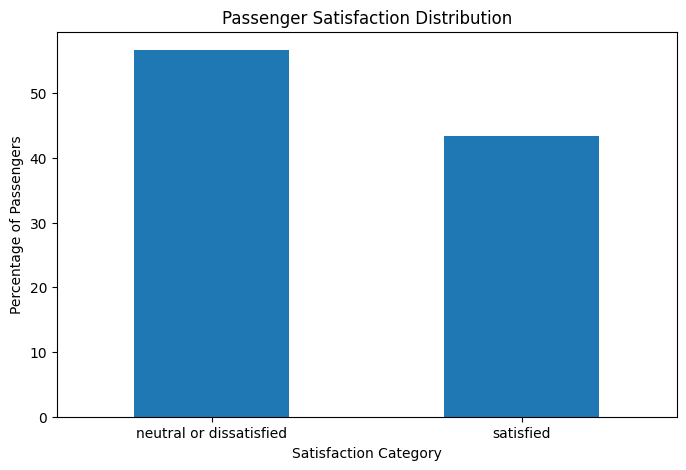

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

satisfaction_percentage.plot(
    kind="bar"
)

plt.title("Passenger Satisfaction Distribution")
plt.xlabel("Satisfaction Category")
plt.ylabel("Percentage of Passengers")

plt.xticks(rotation=0)

plt.show()

### Findings

The dataset shows that 56.67% of passengers are classified as neutral or dissatisfied, while only 43.33% report being satisfied.

This suggests that there is significant room for improvement in the passenger experience. Understanding the factors that differentiate satisfied passengers from dissatisfied passengers will be critical for identifying opportunities to improve customer satisfaction.

### Business Interpretation

The analysis shows that most passengers in the dataset are classified as neutral or dissatisfied rather than satisfied.

This finding suggests that improving customer experience should be a strategic priority for airlines. Since more than half of passengers are not fully satisfied, even small improvements in service quality, operational performance, or customer experience could have a meaningful impact on overall satisfaction levels.

The following analyses will focus on identifying the specific factors that differentiate satisfied passengers from those who are not fully satisfied.

## Business Question 2

### What service attributes differentiate satisfied passengers from dissatisfied passengers?

To improve customer satisfaction, it is important to identify which aspects of the passenger experience show the greatest differences between satisfied and dissatisfied customers.

The analysis will focus on the following service attributes:

- Online Boarding
- Seat Comfort
- Inflight Entertainment
- Cleanliness
- Inflight Service

In [13]:
service_attributes = df.groupby(
    "satisfaction"
)[
    [
        "Online boarding",
        "Seat comfort",
        "Inflight entertainment",
        "Cleanliness",
        "Inflight service"
    ]
].mean()

round(service_attributes,2)

,Online boarding,Seat comfort,Inflight entertainment,Cleanliness,Inflight service
satisfaction,,,,,
neutral or dissatisfied,2.66,3.04,2.89,2.94,3.39
satisfied,4.03,3.97,3.96,3.74,3.97


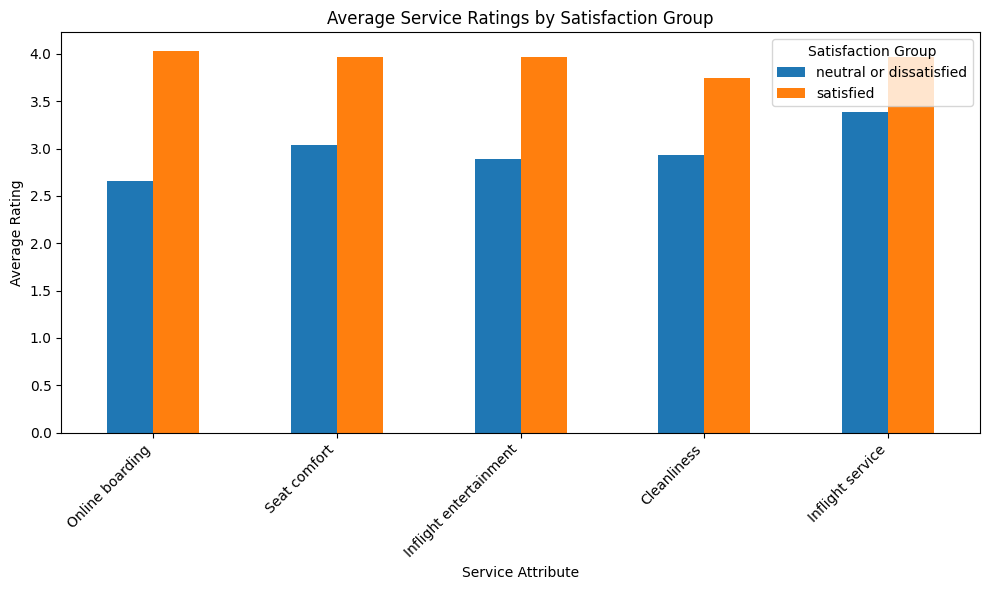

In [14]:
service_attributes.T.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Average Service Ratings by Satisfaction Group")
plt.xlabel("Service Attribute")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Satisfaction Group")
plt.tight_layout()

plt.show()

### Findings

Satisfied passengers reported higher average ratings across all selected service attributes.

The largest differences appear in online boarding, inflight entertainment, and seat comfort. This suggests that digital experience, onboard comfort, and entertainment quality may be important drivers of passenger satisfaction.

### Business Interpretation

The results indicate that satisfied passengers consistently rate all service attributes higher than passengers who are neutral or dissatisfied.

Among the attributes analyzed, Online Boarding shows the largest difference between groups, followed by Inflight Entertainment and Seat Comfort.

These findings suggest that airlines seeking to improve customer satisfaction should prioritize investments in digital boarding processes, onboard comfort, and entertainment services.

## Business Question 3

### How do flight delays affect passenger satisfaction?

Flight delays are one of the most common sources of customer complaints in the airline industry.

This analysis evaluates whether satisfied passengers experience fewer delays than passengers who are neutral or dissatisfied.

### Objective

Determine whether departure and arrival delays are associated with lower passenger satisfaction.

In [15]:
delay_analysis = df.groupby(
    "satisfaction"
)[
    [
        "Departure Delay in Minutes",
        "Arrival Delay in Minutes"
    ]
].mean()

round(delay_analysis,2)

,Departure Delay in Minutes,Arrival Delay in Minutes
satisfaction,,
neutral or dissatisfied,16.50,17.07
satisfied,12.61,12.59


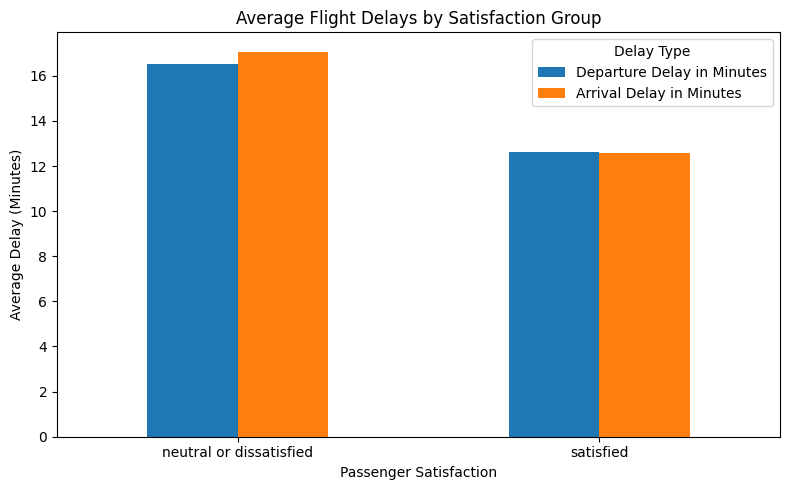

In [16]:
delay_analysis.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Flight Delays by Satisfaction Group")
plt.xlabel("Passenger Satisfaction")
plt.ylabel("Average Delay (Minutes)")

plt.xticks(rotation=0)

plt.legend(title="Delay Type")

plt.tight_layout()

plt.show()

### Findings

Passengers classified as neutral or dissatisfied experienced higher average departure and arrival delays than satisfied passengers.

Neutral or dissatisfied passengers experienced an average departure delay of 16.50 minutes and an average arrival delay of 17.07 minutes.

Satisfied passengers experienced lower average delays, with 12.61 minutes for departure delays and 12.59 minutes for arrival delays.

### Business Interpretation

The results suggest that flight delays negatively affect passenger satisfaction.

However, the differences in average delays between the two groups are relatively modest when compared with the larger differences observed in service-related attributes such as Online Boarding, Seat Comfort, and Inflight Entertainment.

This indicates that while reducing delays remains important, improving the overall passenger experience may have a greater impact on customer satisfaction than operational punctuality alone.

## Business Question 4

### Do Business Class passengers report higher satisfaction levels than Economy passengers?

Travel class plays a significant role in the airline experience.

This analysis evaluates whether passenger satisfaction differs across travel classes and identifies potential differences in customer experience.

In [17]:
class_satisfaction = pd.crosstab(
    df["Class"],
    df["satisfaction"],
    normalize="index"
) * 100

round(class_satisfaction,2)

satisfaction,neutral or dissatisfied,satisfied
Class,,
Business,30.57,69.43
Eco,81.39,18.61
Eco Plus,75.39,24.61


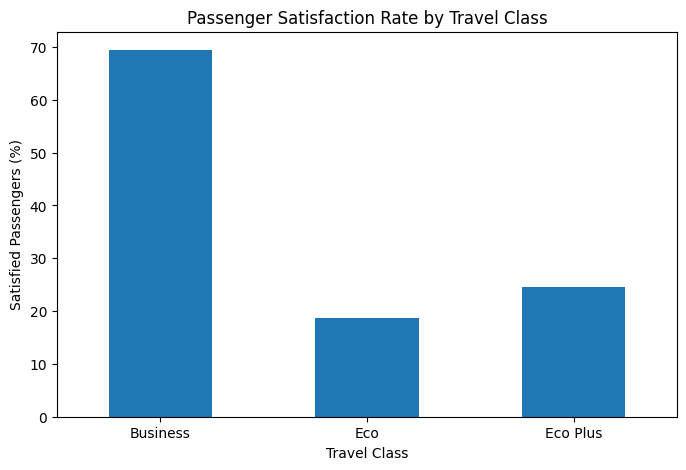

In [18]:
class_satisfaction["satisfied"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Passenger Satisfaction Rate by Travel Class")
plt.xlabel("Travel Class")
plt.ylabel("Satisfied Passengers (%)")

plt.xticks(rotation=0)

plt.show()

### Findings

Passenger satisfaction varies significantly across travel classes.

Business Class passengers reported the highest satisfaction rate at 69.43%.

In contrast, only 24.61% of Eco Plus passengers and 18.61% of Economy passengers reported being satisfied.

The gap between Business Class and Economy passengers exceeds 50 percentage points, indicating substantial differences in the customer experience across travel classes.

### Business Interpretation

Travel class appears to be one of the strongest differentiators of passenger satisfaction.

The significantly higher satisfaction levels reported by Business Class passengers suggest that premium services, additional comfort, and enhanced customer experience contribute substantially to overall satisfaction.

For airlines, these findings highlight the importance of identifying which elements of the Business Class experience could be adapted or extended to Economy passengers in order to improve overall customer satisfaction.

## Business Question 5

### Are loyal customers more satisfied than disloyal customers?

Customer loyalty is a key performance indicator in the airline industry.

This analysis evaluates whether loyal customers report higher satisfaction levels than disloyal customers and explores the relationship between customer retention and passenger experience.

### Objective

Determine whether customer loyalty is associated with higher satisfaction levels.

In [19]:
customer_satisfaction = pd.crosstab(
    df["Customer Type"],
    df["satisfaction"],
    normalize="index"
) * 100

round(customer_satisfaction,2)

satisfaction,neutral or dissatisfied,satisfied
Customer Type,,
Loyal Customer,52.27,47.73
disloyal Customer,76.33,23.67


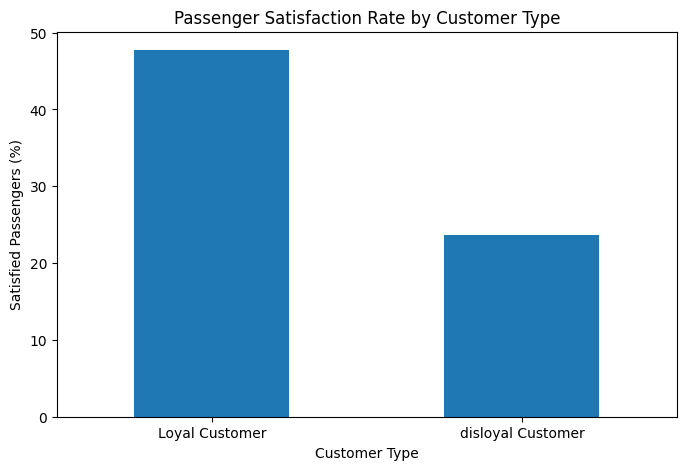

In [20]:
customer_satisfaction["satisfied"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Passenger Satisfaction Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Satisfied Passengers (%)")

plt.xticks(rotation=0)

plt.show()

### Findings

Customer satisfaction differs substantially between loyal and disloyal customers.

Among loyal customers, 47.73% reported being satisfied, compared to only 23.67% of disloyal customers.

This represents a difference of more than 24 percentage points, suggesting a strong relationship between customer loyalty and passenger satisfaction.

### Business Interpretation

Customer loyalty appears to be strongly associated with passenger satisfaction.

The significantly higher satisfaction rates among loyal customers suggest that frequent engagement with the airline may contribute to a more positive travel experience.

These findings highlight the importance of customer retention strategies, loyalty programs, and personalized services as tools for improving long-term customer satisfaction and strengthening customer relationships.

# Key Findings

The analysis identified several factors associated with passenger satisfaction.

### 1. Passenger Satisfaction Remains a Challenge

Only 43.33% of passengers reported being satisfied, while 56.67% were classified as neutral or dissatisfied.

### 2. Service Quality Is a Major Driver of Satisfaction

The largest differences between satisfied and dissatisfied passengers were observed in:

- Online Boarding
- Inflight Entertainment
- Seat Comfort
- Cleanliness

These service-related attributes appear to have a stronger relationship with satisfaction than operational factors alone.

### 3. Flight Delays Negatively Affect Satisfaction

Passengers who were neutral or dissatisfied experienced higher average departure and arrival delays.

However, the impact of delays appears to be smaller than the impact of service quality factors.

### 4. Travel Class Strongly Influences Satisfaction

Business Class passengers reported a satisfaction rate of 69.43%, compared with 24.61% for Eco Plus passengers and 18.61% for Economy passengers.

Travel class was one of the strongest differentiators of passenger satisfaction.

### 5. Loyal Customers Report Higher Satisfaction

Loyal customers were significantly more satisfied than disloyal customers.

This suggests a strong relationship between customer retention and overall customer experience.

# Business Recommendations

Based on the findings of this analysis, the following recommendations are proposed:

### Improve the Digital Boarding Experience

Online Boarding showed the largest difference between satisfied and dissatisfied passengers.

Investing in digital boarding processes could significantly improve customer satisfaction.

### Enhance Onboard Comfort

Seat Comfort and Inflight Entertainment were strongly associated with satisfaction.

Improving seating quality and entertainment options may increase overall passenger satisfaction.

### Continue Reducing Flight Delays

Although delays were not the strongest driver of satisfaction, reducing operational disruptions remains important for maintaining a positive customer experience.

### Focus on Economy Passenger Experience

The largest satisfaction gap was observed between Business and Economy passengers.

Identifying opportunities to improve Economy Class services may provide the greatest potential for increasing overall satisfaction.

### Strengthen Customer Loyalty Programs

Loyal customers reported substantially higher satisfaction levels.

Expanding loyalty benefits and personalized customer experiences could improve both retention and satisfaction.

# Conclusion

This project analyzed airline passenger satisfaction data to identify the factors most strongly associated with customer satisfaction.

The results indicate that service quality factors, particularly Online Boarding, Inflight Entertainment, and Seat Comfort, have a greater influence on satisfaction than flight delays alone.

In addition, Travel Class and Customer Loyalty emerged as strong differentiators of passenger satisfaction.

These findings suggest that airlines seeking to improve customer satisfaction should focus on enhancing service quality, improving the passenger experience across all travel classes, and strengthening customer retention strategies.

By leveraging data-driven insights, airlines can better understand customer expectations and make more informed decisions to improve overall passenger experience.